In [2]:
import torch
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch3d.transforms import rotation_6d_to_matrix, matrix_to_rotation_6d

In [3]:
RETARGETTING_INDICES = [0, 4, 9, 14, 19, 24]

OUTPUT_LEFT_EEF = np.arange(80, 89)
OUTPUT_RIGHT_EEF = np.arange(30, 39)
OUTPUT_HEAD_EEF = np.arange(0, 9)
OUTPUT_LEFT_KEYPOINTS = np.arange(10, 10 + 3 * len(RETARGETTING_INDICES))
assert OUTPUT_LEFT_KEYPOINTS[-1] < OUTPUT_RIGHT_EEF[0]
OUTPUT_RIGHT_KEYPOINTS = np.arange(40, 40 + 3 * len(RETARGETTING_INDICES))
assert OUTPUT_RIGHT_KEYPOINTS[-1] < OUTPUT_LEFT_EEF[0]

def get_eef_kpts_from_prediction(action):
    left_wrist_mat = np.eye(4)
    left_wrist_mat[0:3, 3] = action[OUTPUT_LEFT_EEF[0:3]]
    left_wrist_mat[0:3, 0:3] = rotation_6d_to_matrix(torch.tensor(action[OUTPUT_LEFT_EEF[3:]]).unsqueeze(0)).numpy()

    left_hand_keypoints = np.zeros((25,3))
    left_hand_keypoints[RETARGETTING_INDICES] = action[OUTPUT_LEFT_KEYPOINTS].reshape((6,3))

    right_wrist_mat = np.eye(4)
    right_wrist_mat[0:3, 3] = action[OUTPUT_RIGHT_EEF[0:3]]
    right_wrist_mat[0:3, 0:3] = rotation_6d_to_matrix(torch.tensor(action[OUTPUT_RIGHT_EEF[3:]]).unsqueeze(0)).numpy()

    right_hand_keypoints = np.zeros((25,3))
    right_hand_keypoints[RETARGETTING_INDICES] = action[OUTPUT_RIGHT_KEYPOINTS].reshape((6,3))

    head_mat = np.eye(4)
    head_mat[0:3, 3] = action[OUTPUT_HEAD_EEF[0:3]]
    head_rmat = rotation_6d_to_matrix(torch.tensor(action[OUTPUT_HEAD_EEF[3:]]).unsqueeze(0)).squeeze().numpy()
    head_mat[0:3, 0:3] = head_rmat

    return {
        'left_wrist_mat': left_wrist_mat,
        'left_hand_kpts': left_hand_keypoints,
        'right_wrist_mat': right_wrist_mat,
        'right_hand_kpts': right_hand_keypoints,
        'head_mat': head_mat
    }

In [7]:
synced_hdf5_path = "/home/roger/cross-embodiment-transformer/data/recordings/processed/302-grasp_coke_random-2024_12_09-21_39_30/processed_episode_0.hdf5"

In [9]:
state_list = []
action_list = []

with h5py.File(synced_hdf5_path, "r") as f:
    print(f.keys())
    sample_frame = {}
    for key in f.keys():
        print(f[key])
        sample_frame[key] = f[key][0]
    for i in range(len(f["action"])):
        action_list.append(f["action"][i])
        state_list.append(f["observation.state"][i])


<KeysViewHDF5 ['action', 'observation.image.left', 'observation.image.right', 'observation.state']>
<HDF5 dataset "action": shape (567, 128), type "<f4">
<HDF5 dataset "observation.image.left": shape (567, 8015), type "|u1">
<HDF5 dataset "observation.image.right": shape (567, 7882), type "|u1">
<HDF5 dataset "observation.state": shape (567, 128), type "<f4">


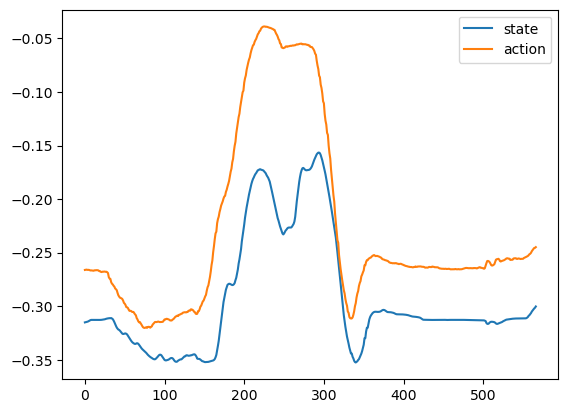

In [13]:
state_x = [state[OUTPUT_RIGHT_EEF[0]] for state in state_list]
state_y = [state[OUTPUT_RIGHT_EEF[1]] for state in state_list]
state_z = [state[OUTPUT_RIGHT_EEF[2]] for state in state_list]

action_x = [action[OUTPUT_RIGHT_EEF[0]] for action in action_list]
action_y = [action[OUTPUT_RIGHT_EEF[1]] for action in action_list]
action_z = [action[OUTPUT_RIGHT_EEF[2]] for action in action_list]


plt.plot(state_z, label="state")
plt.plot(action_z, label="action")
plt.legend()
plt.show()



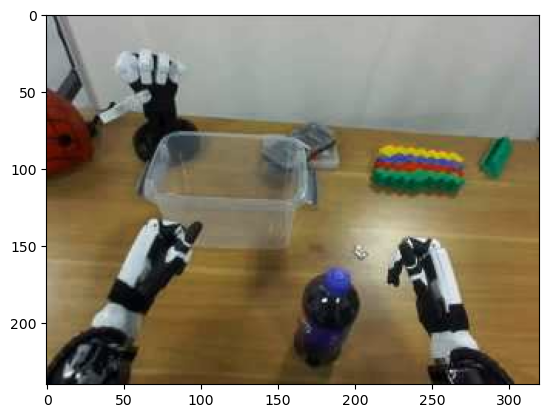

In [18]:
img = sample_frame["observation.image.left"]
decompressed_img = cv2.imdecode(img, cv2.IMREAD_COLOR)
plt.imshow(decompressed_img)
plt.show()


In [19]:
action_dict = get_eef_kpts_from_prediction(sample_frame["action"])

In [21]:
import plotly

# Make a plotly figure of transformation matrices
import plotly.graph_objects as go
import numpy as np

# Function to create coordinate frame visualization from transformation matrix
def plot_coordinate_frame(fig, matrix, name, scale=0.1, line_width=5):
    # Extract origin (translation) from the matrix
    origin = matrix[0:3, 3]
    
    # Extract rotation axes (each column of the rotation matrix)
    x_axis = matrix[0:3, 0] * scale
    y_axis = matrix[0:3, 1] * scale
    z_axis = matrix[0:3, 2] * scale
    
    # Add lines for each axis
    # X-axis (red)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], origin[0] + x_axis[0]],
        y=[origin[1], origin[1] + x_axis[1]],
        z=[origin[2], origin[2] + x_axis[2]],
        mode='lines',
        line=dict(color='red', width=line_width),
        name=f"{name} X-axis"
    ))
    
    # Y-axis (green)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], origin[0] + y_axis[0]],
        y=[origin[1], origin[1] + y_axis[1]],
        z=[origin[2], origin[2] + y_axis[2]],
        mode='lines',
        line=dict(color='green', width=line_width),
        name=f"{name} Y-axis"
    ))
    
    # Z-axis (blue)
    fig.add_trace(go.Scatter3d(
        x=[origin[0], origin[0] + z_axis[0]],
        y=[origin[1], origin[1] + z_axis[1]],
        z=[origin[2], origin[2] + z_axis[2]],
        mode='lines',
        line=dict(color='blue', width=line_width),
        name=f"{name} Z-axis"
    ))
    
    # Add a marker for the origin
    fig.add_trace(go.Scatter3d(
        x=[origin[0]],
        y=[origin[1]],
        z=[origin[2]],
        mode='markers',
        marker=dict(color='black', size=5),
        name=f"{name} Origin"
    ))

# Create a 3D figure
fig = go.Figure()

# Plot coordinate frames for each transformation matrix
plot_coordinate_frame(fig, action_dict['left_wrist_mat'], "Left Wrist")
plot_coordinate_frame(fig, action_dict['right_wrist_mat'], "Right Wrist")
plot_coordinate_frame(fig, action_dict['head_mat'], "Head")

# Set layout
fig.update_layout(
    title="Transformation Matrices Visualization",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode='data'
    ),
    width=800,
    height=800,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()